# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_games = pd.read_csv('video_games_sales.csv')

df_games = df_games.dropna()

df_games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [2]:
df_games.describe(include='all')


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291,16291,16291.000000,16291,16291,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
unique,NaN,11325,31,NaN,12,576,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2131,NaN,3251,1339,NaN,NaN,NaN,NaN,NaN
mean,8290.190228,NaN,NaN,2006.405561,NaN,NaN,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,NaN,NaN,5.832412,NaN,NaN,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.480000



Target Feature: Global_Sales


c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


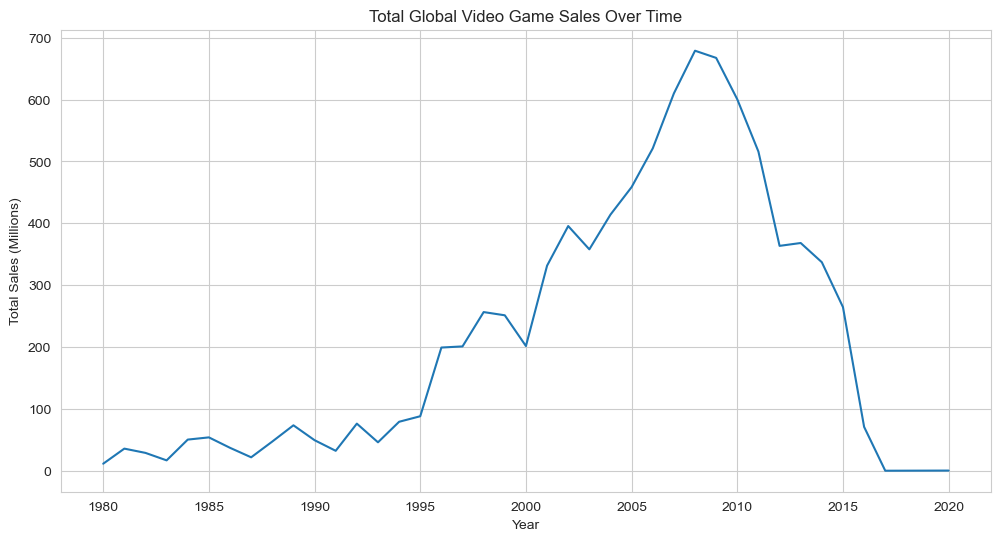

In [3]:
print("\nTarget Feature: Global_Sales")

sns.set_style("whitegrid")

# Visualization 1: Sales over Time (Numerical vs. Numerical)
# showing the 'Golden Age' of physical game sales
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_games, x='Year', y='Global_Sales', estimator='sum', errorbar=None)
plt.title('Total Global Video Game Sales Over Time')
plt.ylabel('Total Sales (Millions)')
plt.show()

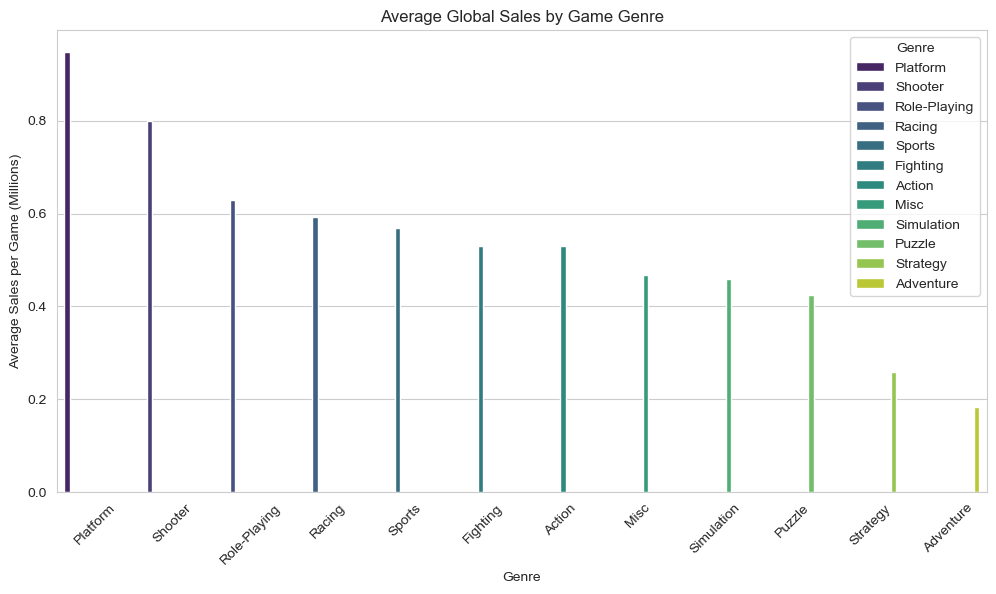

In [4]:
# Visualization 2: Global Sales by Genre (Categorical vs. Numerical)
# We calculate the sum sales per genre to see the leaders
plt.figure(figsize=(12, 6))
genre_sales = df_games.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis', hue=genre_sales.index)
plt.title('Average Global Sales by Game Genre')
plt.xticks(rotation=45)
plt.ylabel('Average Sales per Game (Millions)')
plt.show()

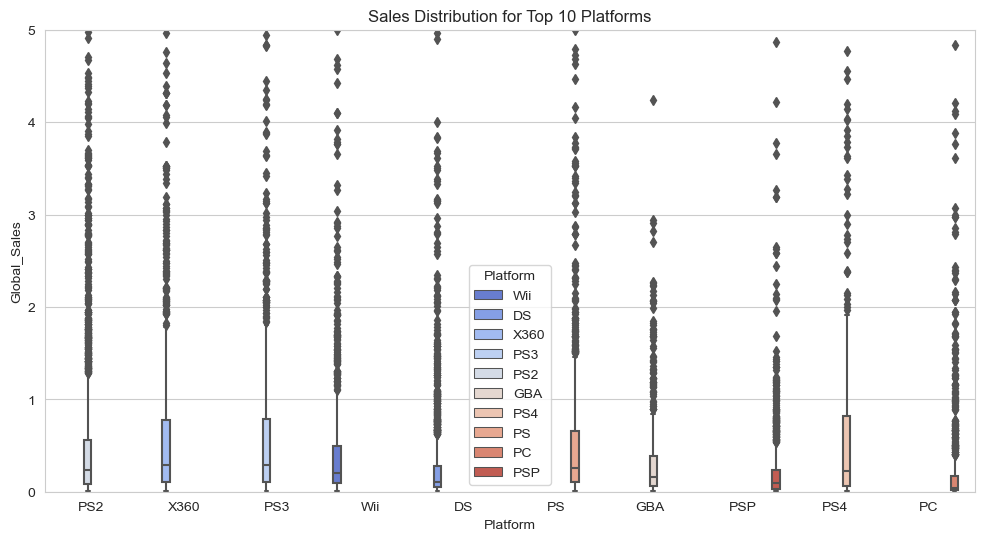

In [5]:
# Visualization 3: Top 10 Platforms by Sales (Categorical vs. Numerical)
# We filter to the top 10 platforms so the chart isn't too crowded
top_platforms = df_games.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10).index
df_top_platforms = df_games[df_games['Platform'].isin(top_platforms)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_platforms, x='Platform', y='Global_Sales', order=top_platforms, palette='coolwarm', hue='Platform')
plt.title('Sales Distribution for Top 10 Platforms')
plt.ylim(0, 5) # Zoom in to see the boxes (ignoring massive outliers like Wii Sports)
plt.show()

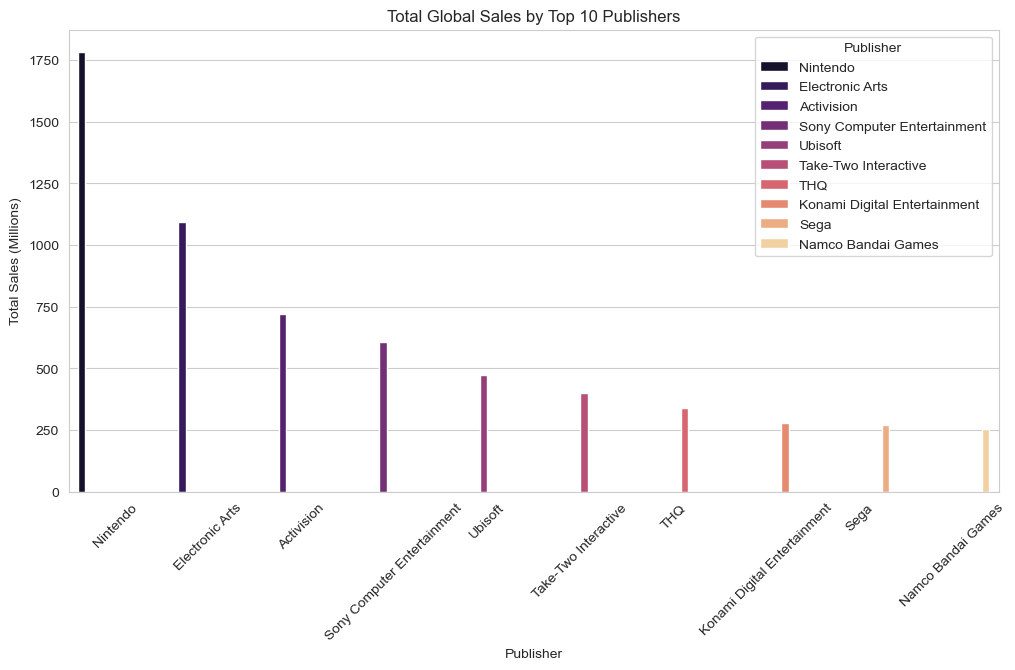

In [6]:
# Visualization 4: Top 10 Publishers by Total Global Sales (Categorical vs. Numerical)
# We sum the sales to see who dominates the market share
top_publishers = df_games.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.index, y=top_publishers.values, palette='magma', hue=top_publishers.index)
plt.title('Total Global Sales by Top 10 Publishers')
plt.xticks(rotation=45)
plt.ylabel('Total Sales (Millions)')
plt.show()

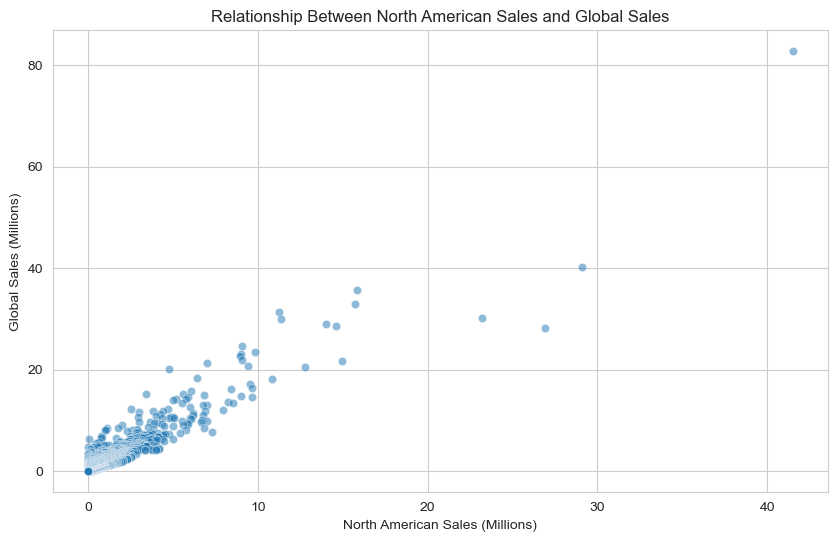

In [7]:
# Visualization 5: North American Sales vs. Global Sales (Numerical vs. Numerical)
# Showing how strongly performance in the biggest market (NA) predicts Global success
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_games, x='NA_Sales', y='Global_Sales', alpha=0.5)
plt.title('Relationship Between North American Sales and Global Sales')
plt.xlabel('North American Sales (Millions)')
plt.ylabel('Global Sales (Millions)')
plt.show()

This dataset is about globalk video game sales. North American Sales have the strongest correlation with the target, Global Sales, with a nearly perfect linear relationship between the two. Temporal features are also meaningful; the total volume of games sold peaked substantially during the industry's "Golden Age" in around 2008, and then dramatically declined afterwards. The genre and the publisher of a video game are the two strongest predictors of revenue. Platformers, Shooters, Nintendo, and Electronic Arts dominate the market. However, the genre Platform is the least predictive of a typical game's revenues, as its median revenues are consistently low for all consoles. Despite this very high ceiling for "mega-hits" for several platforms, the video-game industry as a whole is found by the analysis to be "hit-driven", with regional performance, release timing, and genre driving revenue worldwide, not the platform alone.